In [22]:
import requests
import pandas as pd

In [23]:
def get_history(coin, days):

    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"

    params = {
        "vs_currency" : "jpy",
        "days": days
    }

    response = requests.get(url,params=params)

    data = response.json()

    df = pd.DataFrame(
        data["prices"],
        columns=["Timestamp", "Price"]
    )

    df["Date"] = pd.to_datetime(
        df["Timestamp"],
        unit="ms"
    )

    df["Coin"] = coin

    return df.drop(columns="Timestamp")

In [24]:
coins = [
    "bitcoin",
    "ethereum",
    "solana"
]

all_df = []

for coin in coins:

    df = get_history(coin, 365)

    all_df.append(df)

crypto_df = pd.concat(
    all_df,
    ignore_index=True
)


In [25]:
crypto_df

,Price,Date,Coin
0,1.669506e+07,2025-08-02 00:00:00,bitcoin
1,1.657900e+07,2025-08-03 00:00:00,bitcoin
2,1.677231e+07,2025-08-04 00:00:00,bitcoin
3,1.698070e+07,2025-08-05 00:00:00,bitcoin
4,1.679588e+07,2025-08-06 00:00:00,bitcoin
...,...,...,...
1093,1.210922e+04,2026-07-29 00:00:00,solana
1094,1.202030e+04,2026-07-30 00:00:00,solana
1095,1.193748e+04,2026-07-31 00:00:00,solana
1096,1.145975e+04,2026-08-01 00:00:00,solana


前処理

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Price   366 non-null    float64       
 1   Date    366 non-null    datetime64[ns]
 2   Coin    366 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 8.7+ KB


In [27]:
df.head()

,Price,Date,Coin
0,23986.333503,2025-08-02,solana
1,23330.782622,2025-08-03,solana
2,23762.826017,2025-08-04,solana
3,24970.853939,2025-08-05,solana
4,24136.872136,2025-08-06,solana


In [28]:
df.describe()

,Price,Date
count,366.000000,366
mean,19405.166057,2026-01-31 11:59:55.519125760
min,9968.504519,2025-08-02 00:00:00
25%,13223.588995,2025-11-01 06:00:00
50%,17273.755432,2026-01-31 12:00:00
75%,24940.047468,2026-05-02 18:00:00
max,36628.871293,2026-08-01 23:32:40
std,7369.584695,NaN


In [29]:
crypto_df["Date"] = pd.to_datetime(df["Date"])
crypto_df["Year"] = crypto_df["Date"].dt.year
crypto_df["Month"] = crypto_df["Date"].dt.month
crypto_df["Weekday"] = crypto_df["Date"].dt.day_name()

crypto_df

,Price,Date,Coin,Year,Month,Weekday
0,1.669506e+07,2025-08-02,bitcoin,2025.0,8.0,Saturday
1,1.657900e+07,2025-08-03,bitcoin,2025.0,8.0,Sunday
2,1.677231e+07,2025-08-04,bitcoin,2025.0,8.0,Monday
3,1.698070e+07,2025-08-05,bitcoin,2025.0,8.0,Tuesday
4,1.679588e+07,2025-08-06,bitcoin,2025.0,8.0,Wednesday
...,...,...,...,...,...,...
1093,1.210922e+04,NaT,solana,NaN,NaN,NaN
1094,1.202030e+04,NaT,solana,NaN,NaN,NaN
1095,1.193748e+04,NaT,solana,NaN,NaN,NaN
1096,1.145975e+04,NaT,solana,NaN,NaN,NaN


土日と平日で違いはある？

In [30]:
crypto_df["DayType"] = crypto_df["Weekday"].apply(
    lambda x:"Weekdend"
    if x in ["Saturday","Sunday"]
    else "Weekday"
)
crypto_df

,Price,Date,Coin,Year,Month,Weekday,DayType
0,1.669506e+07,2025-08-02,bitcoin,2025.0,8.0,Saturday,Weekdend
1,1.657900e+07,2025-08-03,bitcoin,2025.0,8.0,Sunday,Weekdend
2,1.677231e+07,2025-08-04,bitcoin,2025.0,8.0,Monday,Weekday
3,1.698070e+07,2025-08-05,bitcoin,2025.0,8.0,Tuesday,Weekday
4,1.679588e+07,2025-08-06,bitcoin,2025.0,8.0,Wednesday,Weekday
...,...,...,...,...,...,...,...
1093,1.210922e+04,NaT,solana,NaN,NaN,NaN,Weekday
1094,1.202030e+04,NaT,solana,NaN,NaN,NaN,Weekday
1095,1.193748e+04,NaT,solana,NaN,NaN,NaN,Weekday
1096,1.145975e+04,NaT,solana,NaN,NaN,NaN,Weekday


In [31]:
result = (
    crypto_df.groupby("DayType")["Price"]
    .mean()
    .round(2)
)

print(result)

DayType
Weekday      3677087.27
Weekdend    13311427.43
Name: Price, dtype: float64


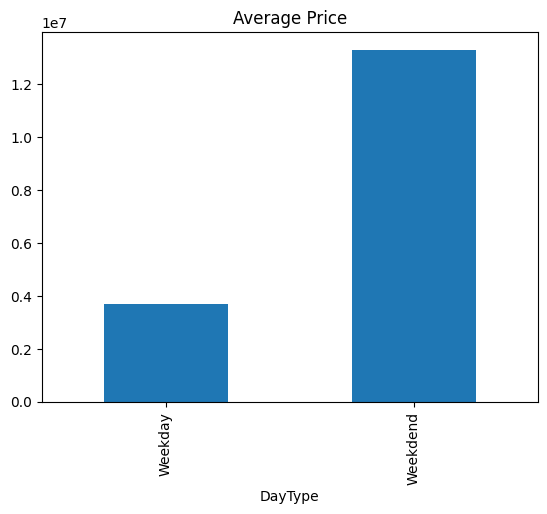

In [32]:
import matplotlib.pyplot as plt

result.plot(kind="bar")
plt.title("Average Price")

plt.show()